In [ ]:
# import packages
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# read in data
df = pd.read_csv('cleaned_data.csv')

In [ ]:
# exploration
df.head()
df.tail()

,reference,input,output,label,hallucination_type_realized,question_type,hallucination_type_encouraged
7815,Dashboards are a collection of charts assemble...,How do dashboards help users view and analyze ...,Dashboards combine multiple charts into a sing...,factual,NaN,Default question type,Non-synthetic. No hallucination encouragement
7816,'MongoDB partners understand your needs and de...,How does the MongoDB partner ecosystem benefit...,It provides the services and knowledge require...,factual,NaN,Default question type,Non-synthetic. No hallucination encouragement
7817,"Las plaquetas, también conocidas como tromboci...",¿Qué función desempeñan las plaquetas en el cu...,They are essential for blood clotting.,factual,NaN,Default question type,Non-synthetic. No hallucination encouragement
7818,Macroeconomics and microeconomics are the two ...,What are the two primary branches of economics?,Macroeconomics and microeconomics.,factual,NaN,Default question type,Non-synthetic. No hallucination encouragement
7819,Un implante coclear es un dispositivo electrÃ³...,What are the two parts of an implant coclear?,One part external that is placed behind the ea...,factual,NaN,Default question type,Non-synthetic. No hallucination encouragement


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7820 entries, 0 to 7819
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   reference                      7820 non-null   object
 1   input                          7820 non-null   object
 2   output                         7820 non-null   object
 3   label                          7820 non-null   object
 4   hallucination_type_realized    2659 non-null   object
 5   question_type                  7820 non-null   object
 6   hallucination_type_encouraged  7820 non-null   object
dtypes: object(7)
memory usage: 427.8+ KB


In [ ]:
# map target string labels to binary numbers for classification
# 'hallucinated' -> 1, 'not hallucinated' -> 0
df['target_label'] = df['label'].map({'hallucinated': 1, 'factual': 0})

In [ ]:
# sentence similarity score

# start by initializing sentence encoder which is not llm?
model = SentenceTransformer('all-MiniLM-L6-v2')
# encode columns into vector spaces
ref_embeddings = model.encode(df['reference'].tolist(), show_progress_bar=True)
out_embeddings = model.encode(df['output'].tolist(), show_progress_bar=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/245 [00:00<?, ?it/s]

Batches:   0%|          | 0/245 [00:00<?, ?it/s]

In [ ]:
# Cosine Similarity: Measures the angle between the two vectors
# range is -1 to 1 (closer to 1 means identical meaning)
cosine_scores = np.diag(cosine_similarity(ref_embeddings, out_embeddings))

# Euclidean Distance to measure the straight-line distance between vectors
euclidean_distances = np.linalg.norm(ref_embeddings - out_embeddings, axis=1)

# length ratio to compare lengths for output and reference
df['len_ratio'] = df['output'].str.len() / df['reference'].str.len()

# create feature dataframe to pass to GMM later
# this was before adding min window
similarity_features = pd.DataFrame({
    'cosine_sim': cosine_scores, # the cosine similarity scores
    'euclidean_dist': euclidean_distances, # euclidean distances
    'length_anomaly_ratio': df['len_ratio'].values, # catches structural inflation
    #
    'synthetic_flag': df['hallucination_type_encouraged'].apply(lambda x: 0 if x == 'none' else 1)
})

In [ ]:
# initialize same model for consistency
model = SentenceTransformer('all-MiniLM-L6-v2')

# make function that compares in 3 word chunks
def get_min_window_similarity(row, window_size=3):
    ref_text = str(row['reference'])
    out_text = str(row['output'])

    out_words = out_text.split()

    # if the output sentence is too short, use global embedding
    if len(out_words) <= window_size:
        ref_emb = model.encode([ref_text])
        out_emb = model.encode([out_text])
        return cosine_similarity(ref_emb, out_emb)[0][0]

    # create sliding windows from the output sentence
    windows = []
    for i in range(len(out_words) - window_size + 1):
        window_phrase = " ".join(out_words[i:i+window_size])
        windows.append(window_phrase)

    # vectorize the reference text and all generated windows at once
    ref_emb = model.encode([ref_text])
    window_embs = model.encode(windows)

    # calculate cosine similarity between the reference and every window
    sim_matrix = cosine_similarity(window_embs, ref_emb)

    # return the minimum score (the most detached/hallucinated window)
    return np.min(sim_matrix)

# apply the function to the dataframe
df['min_window_sim'] = df.apply(get_min_window_similarity, axis=1)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


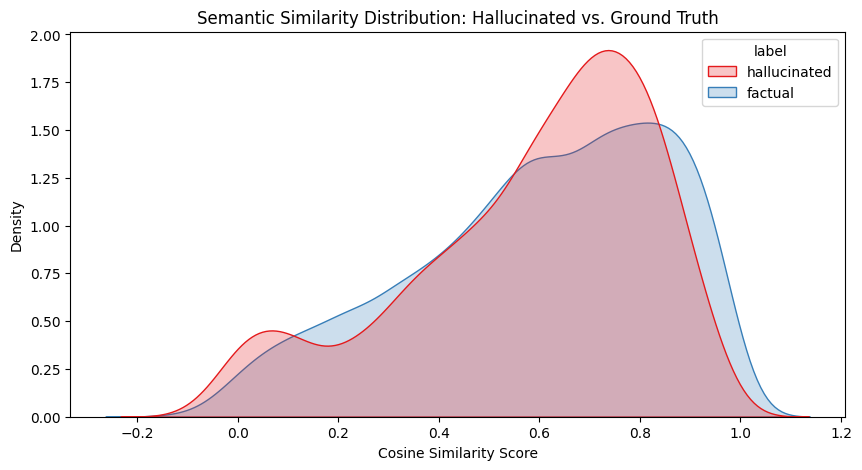

In [ ]:
plt.figure(figsize=(10, 5))
# Plot the distribution of cosine similarity for hallucinated vs non-hallucinated text
sns.kdeplot(data=df, x=cosine_scores, hue='label', fill=True, common_norm=False, palette='Set1')
plt.xlabel('Cosine Similarity Score')
plt.title('Semantic Similarity Distribution: Hallucinated vs. Ground Truth')
plt.show()

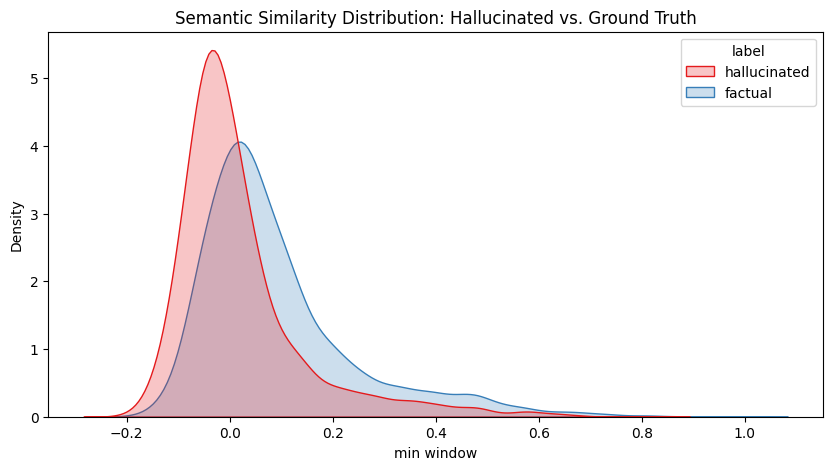

In [ ]:
plt.figure(figsize=(10, 5))
# Plot the distribution of x for hallucinated vs non-hallucinated text
sns.kdeplot(data=df, x='min_window_sim', hue='label', fill=True, common_norm=False, palette='Set1')
plt.xlabel('min window')
plt.title('Semantic Similarity Distribution: Hallucinated vs. Ground Truth')
plt.show()

In [ ]:
print("Calculating sliding window similarities")
# calculate advanced sliding window metric
min_window_scores = df.apply(get_min_window_similarity, axis=1).values

print("Calculating global vector embeddings")
# calculate standard global cosine metric for comparison
ref_embeddings = model.encode(df['reference'].tolist(), show_progress_bar=False)
out_embeddings = model.encode(df['output'].tolist(), show_progress_bar=False)
global_cosine_scores = np.diag(cosine_similarity(ref_embeddings, out_embeddings))

# calculate structural length metrics
len_ratios = df['output'].str.len() / df['reference'].str.len()
abs_len_diffs = np.abs(df['output'].str.len() - df['reference'].str.len())

# create final mapped DataFrame for GMM pipeline
gmm_ready_dataframe = pd.DataFrame({
    # text identifiers kept for row verification/debugging
    'reference_text': df['reference'].values,
    'output_text': df['output'].values,

    # the feature matrix (columns for the GMM to train on)
    'global_cosine': global_cosine_scores,
    'min_window_cosine': min_window_scores,
    'euclidean_dist': euclidean_distances,
    'length_ratio': len_ratios.values,
    'char_length_diff': abs_len_diffs.values,

    # use this for final validation scoring
    'ground_truth_label': df['label'].values
})

# preview of mapping - main points we care about
print("mapped GMM Feature Matrix Preview")
print(gmm_ready_dataframe[['global_cosine', 'min_window_cosine', 'euclidean_dist', 'length_ratio']].head())

Calculating sliding window similarities
Calculating global vector embeddings
mapped GMM Feature Matrix Preview
   global_cosine  min_window_cosine  euclidean_dist  length_ratio
0       0.557387          -0.028328        0.940865      0.192412
1       0.545204          -0.017767        0.953725      0.295285
2       0.619412           0.000048        0.872454      0.700730
3       0.682477          -0.070343        0.796898      1.103837
4       0.656494          -0.006869        0.828862      0.596154


In [ ]:
# Save to a file so your team member can just do pd.read_csv('similarity_features.csv')
gmm_ready_dataframe.to_csv('similarity_features.csv', index=False)

In [ ]:
# used colab for gpu
from google.colab import files
files.download('similarity_features.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>